# 07 -- Risk & Forecasting

## Research Question
Where is supply-chain risk concentrated across the network, and what does a properly validated forecast say about Malaysia's export trajectory to 2030?

## Data
Supply Chain Risk Index (`data/processed/supply_chain_risk_index.csv`, DERIVED from World Bank + UN Comtrade + Pink Sheet). Malaysia export forecast (`data/processed/malaysia_export_forecast_2026_2030.csv`, DERIVED from DOSM). Nickel Monte Carlo (`data/processed/nickel_monte_carlo_12m.csv`).

## Method
Risk index: four equal-weighted, min-max normalised pillars (import dependency, logistics fragility, trade-partner concentration, commodity exposure), sensitivity-tested (a single alternative weighting, plus a 1,000-draw random-weight Monte Carlo added after external review). Forecast: four models (naive, naive+drift, ETS, ARIMA) compared on a genuine 5-year rolling backtest, then stress-tested against three real historically-anchored shock scenarios (also added after external review). Monte Carlo: 10,000-path historical bootstrap on nickel prices. Full methodology in `docs/METHODOLOGY.md`, `docs/FORECASTING.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
risk = pd.read_csv('../data/processed/supply_chain_risk_index.csv')
print("Highest supply-chain risk (top 10 of 59):")
print(risk[['rank','Country','Region','supply_chain_risk_score']].head(10).round(1).to_string(index=False))
print("\nLowest risk (bottom 5):")
print(risk[['rank','Country','Region','supply_chain_risk_score']].tail(5).round(1).to_string(index=False))

Highest supply-chain risk (top 10 of 59):
 rank              Country                 Region  supply_chain_risk_score
    1                 Cuba          Latin America                     68.5
    2   Iran, Islamic Rep.            Middle East                     61.2
    3             Mongolia              East Asia                     59.7
    4   Russian Federation                 Europe                     52.7
    5 Hong Kong SAR, China              East Asia                     52.2
    6               Mexico          Latin America                     51.3
    7                 Iraq            Middle East                     50.8
    8           Bangladesh South & Southeast Asia                     49.3
    9              Algeria                 Africa                     47.0
   10   Dominican Republic          Latin America                     45.8

Lowest risk (bottom 5):
 rank       Country        Region  supply_chain_risk_score
   55         China     East Asia                

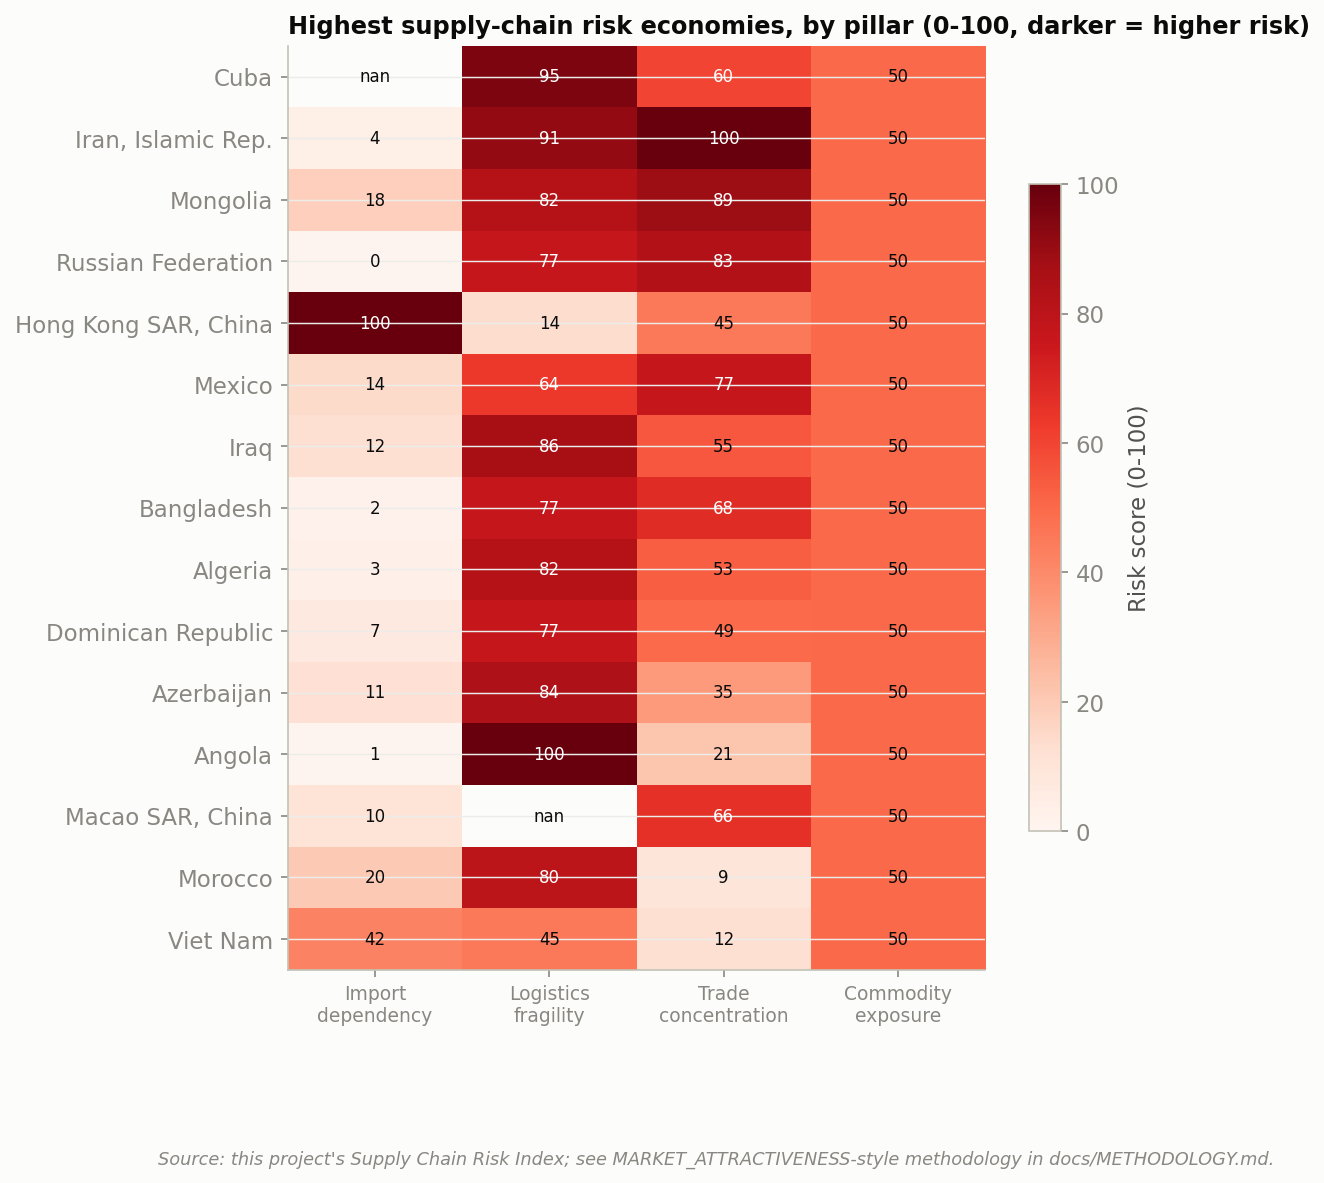

In [3]:
display(Image('../outputs/figures/10_risk_heatmap.png', width=650))

In [4]:
backtest = pd.read_csv('../data/processed/malaysia_export_forecast_backtest.csv')
print("Forecast model backtest (5-year rolling, 1-step-ahead RMSE):")
print(backtest.round(0).to_string(index=False))

Forecast model backtest (5-year rolling, 1-step-ahead RMSE):
      model          MAE         RMSE  MAPE_pct
naive_drift 1.312439e+11 1.626521e+11       9.0
      naive 1.532680e+11 1.783257e+11      10.0
      arima 1.736915e+11 1.929610e+11      12.0
   ets_holt 2.105725e+11 2.730402e+11      14.0


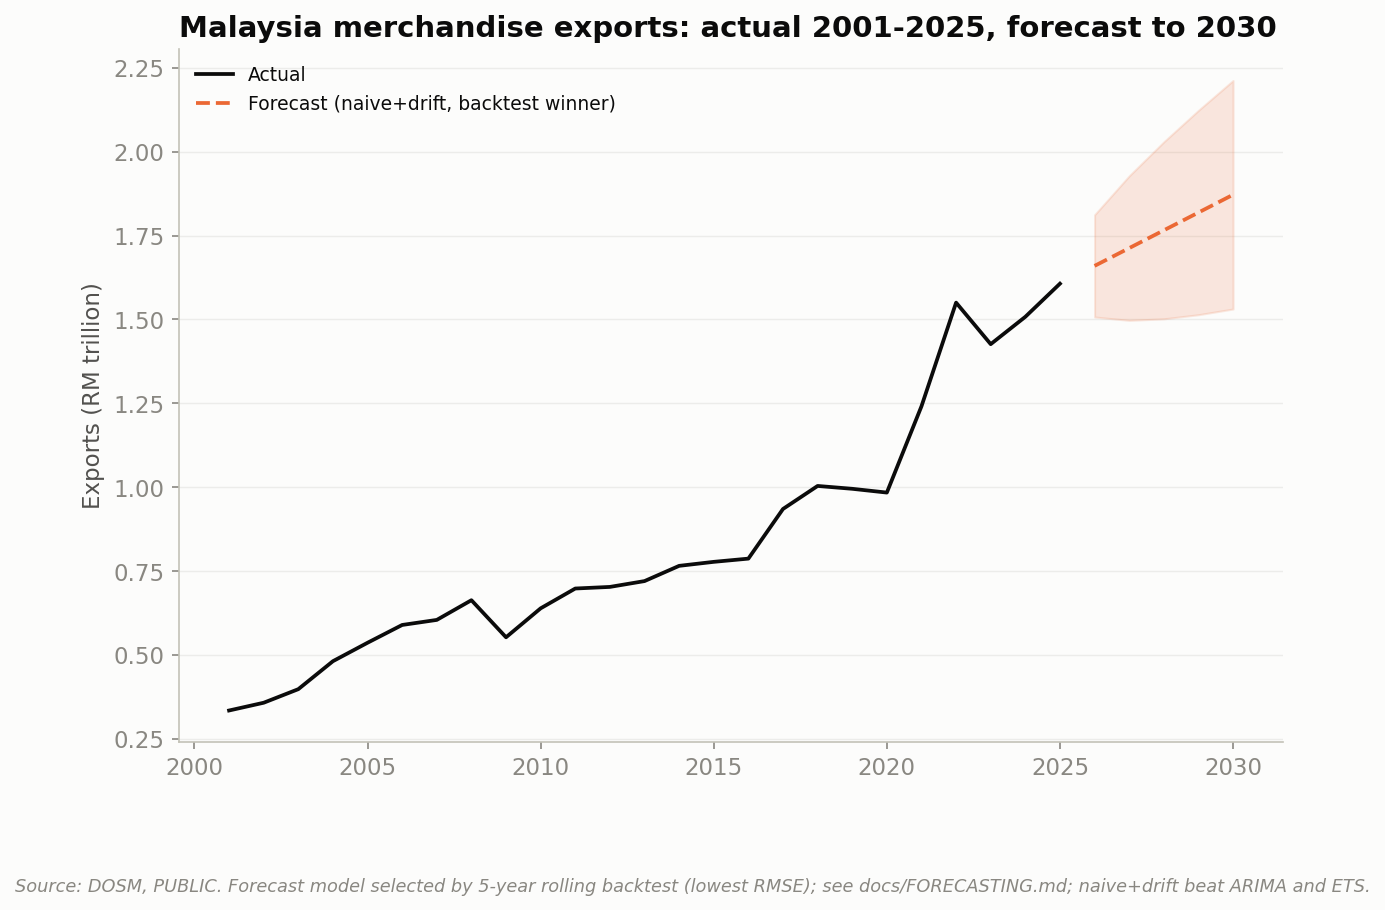

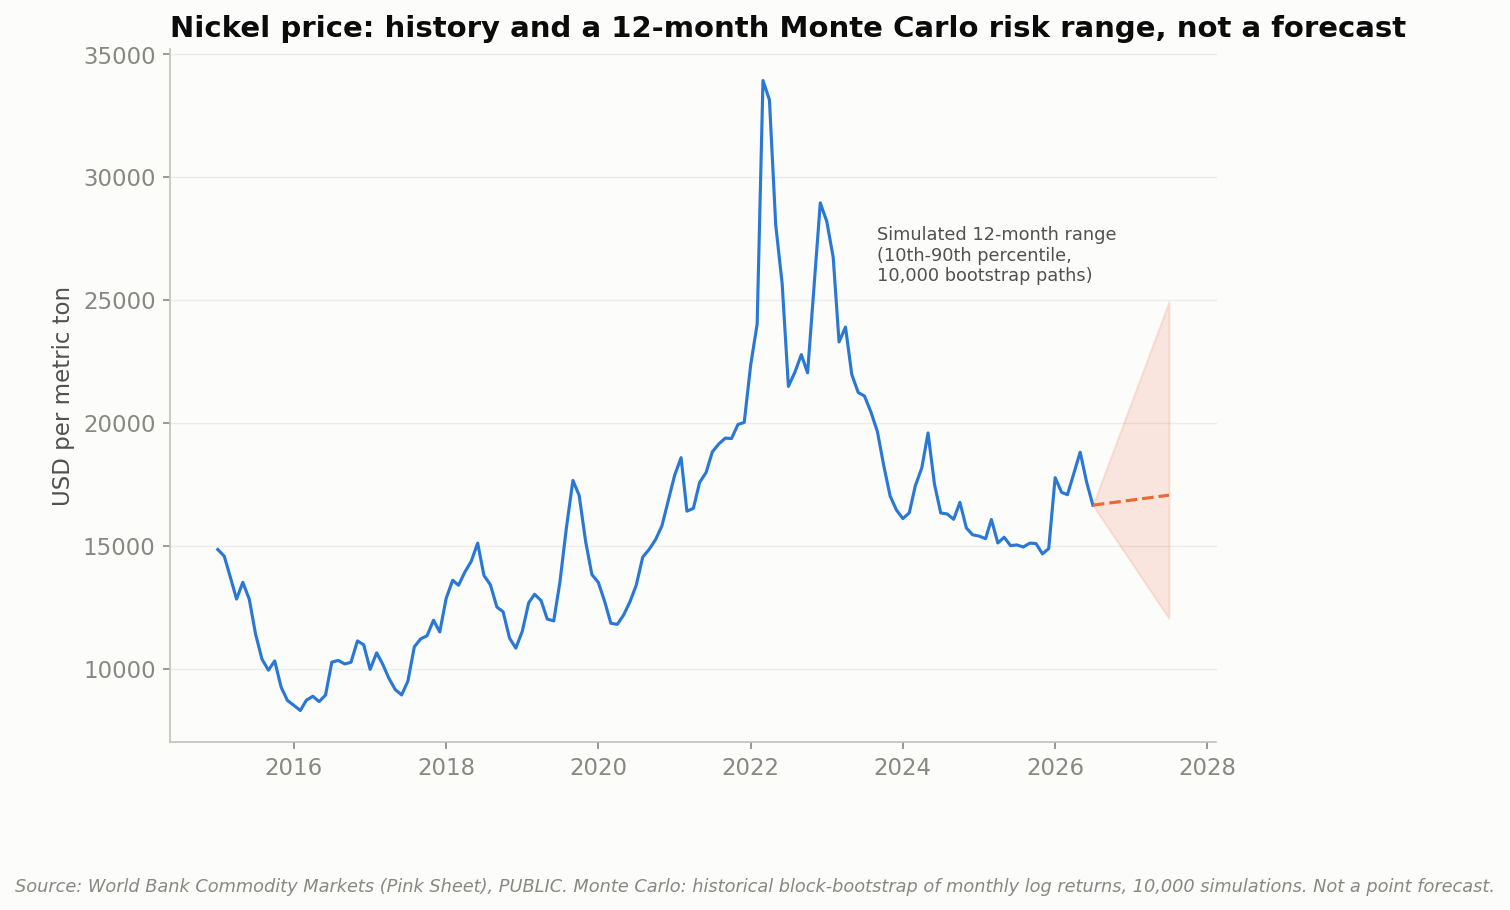

In [5]:
display(Image('../outputs/figures/13_malaysia_export_forecast.png', width=750))
display(Image('../outputs/figures/07_nickel_price_montecarlo.png', width=650))

## Sensitivity & Stress-Testing (Added After External Review)

A single alternative-weighting check and a forecast kept permanently separate from the shock scenarios were both flagged in external review as too thin. This section adds a proper weight-sensitivity Monte Carlo for the risk index and a real, historically-anchored stress test for the forecast.

In [6]:
sens = pd.read_csv('../data/processed/risk_index_weight_sensitivity.csv')
mys_sens = sens[sens['Country'].str.contains('Malaysia', na=False)].iloc[0]
print(f"Malaysia base rank: {int(mys_sens['base_rank'])}")
print(f"Malaysia rank across 1,000 random pillar-weight draws (5th-95th pct): "
      f"{int(mys_sens['rank_p5'])}-{int(mys_sens['rank_p95'])} of {len(sens)} complete-data countries")
print(f"\nWidest rank bands (least stable rankings):")
print(sens.sort_values('rank_band_width', ascending=False)[['Country','base_rank','rank_p5','rank_p95','rank_band_width']].head(6).to_string(index=False))

Malaysia base rank: 29
Malaysia rank across 1,000 random pillar-weight draws (5th-95th pct): 6-41 of 56 complete-data countries

Widest rank bands (least stable rankings):
             Country  base_rank  rank_p5  rank_p95  rank_band_width
           Singapore         47      5.0      56.0             51.0
             Belgium         39      7.0      52.0             45.0
              Canada         22      7.0      51.0             44.0
         Netherlands         43     10.0      53.0             43.0
            Ethiopia         16      7.0      47.0             40.0
Hong Kong SAR, China          5      1.0      40.0             39.0


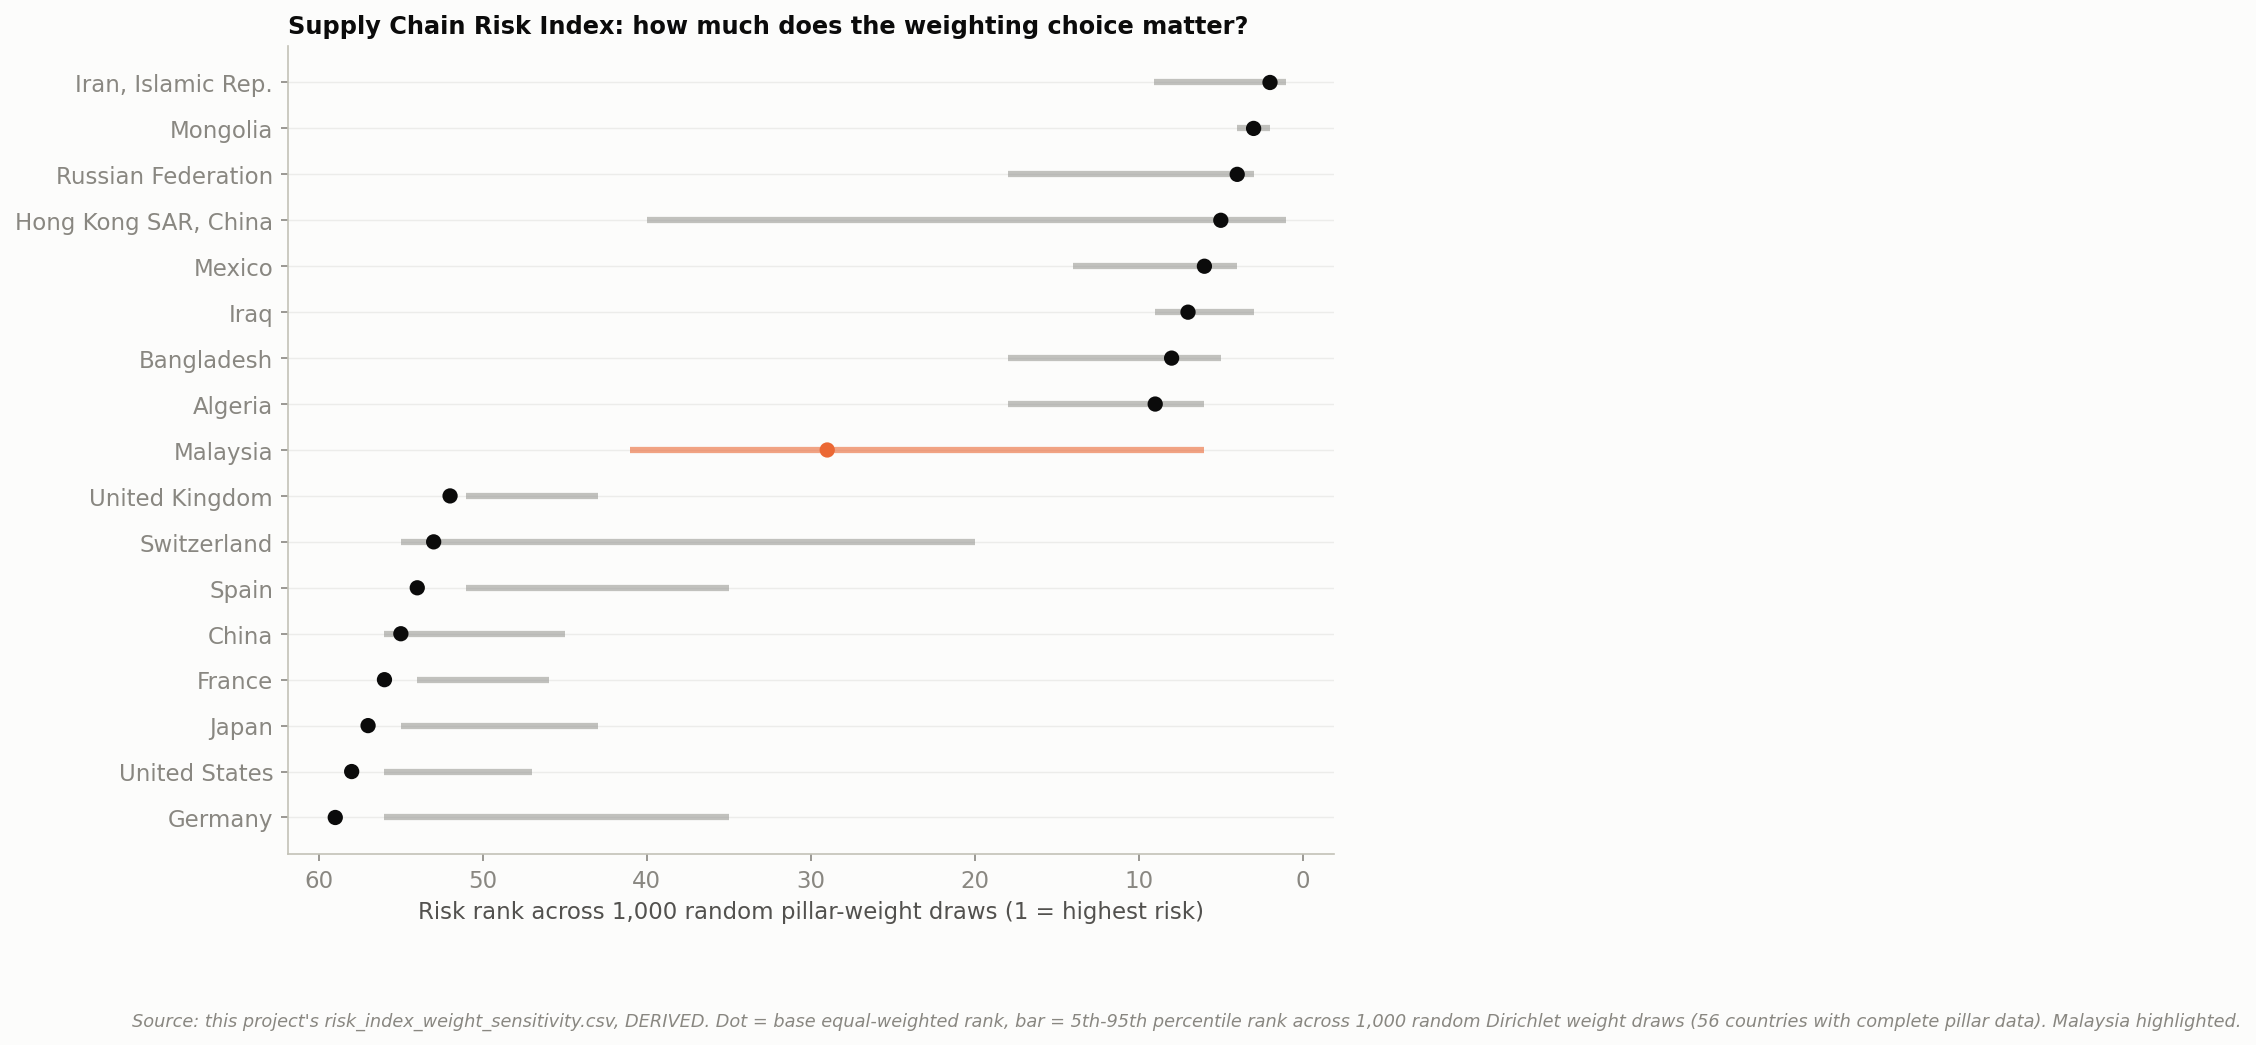

In [7]:
display(Image('../outputs/figures/18_risk_index_weight_sensitivity.png', width=700))

In [8]:
stress = pd.read_csv('../data/processed/malaysia_export_forecast_stress_test.csv')
print(stress.round(0).to_string(index=False))
b2030 = stress['baseline_naive_drift'].iloc[-1]
print(f"\n2030 baseline: RM{b2030/1e12:.2f}T")
print(f"2030 under Scenario H (recession): RM{stress['scenario_H_recession'].iloc[-1]/1e12:.2f}T")
print(f"2030 under Scenario D (trade tension): RM{stress['scenario_D_trade_tension'].iloc[-1]/1e12:.2f}T")
print(f"2030 under Scenario G (energy shock band): RM{stress['scenario_G_energy_shock_lower'].iloc[-1]/1e12:.2f}T to "
      f"RM{stress['scenario_G_energy_shock_upper'].iloc[-1]/1e12:.2f}T")

 year  baseline_naive_drift  scenario_H_recession  scenario_D_trade_tension  scenario_G_energy_shock_upper  scenario_G_energy_shock_lower
 2026          1.659481e+12          1.588319e+12              1.592843e+12                   1.745993e+12                   1.572969e+12
 2027          1.712489e+12          1.641326e+12              1.645851e+12                   1.801764e+12                   1.623213e+12
 2028          1.765497e+12          1.694334e+12              1.698859e+12                   1.857536e+12                   1.673458e+12
 2029          1.818505e+12          1.747342e+12              1.751867e+12                   1.913307e+12                   1.723702e+12
 2030          1.871512e+12          1.800350e+12              1.804874e+12                   1.969078e+12                   1.773947e+12

2030 baseline: RM1.87T
2030 under Scenario H (recession): RM1.80T
2030 under Scenario D (trade tension): RM1.80T
2030 under Scenario G (energy shock band): RM1.77T to RM1.

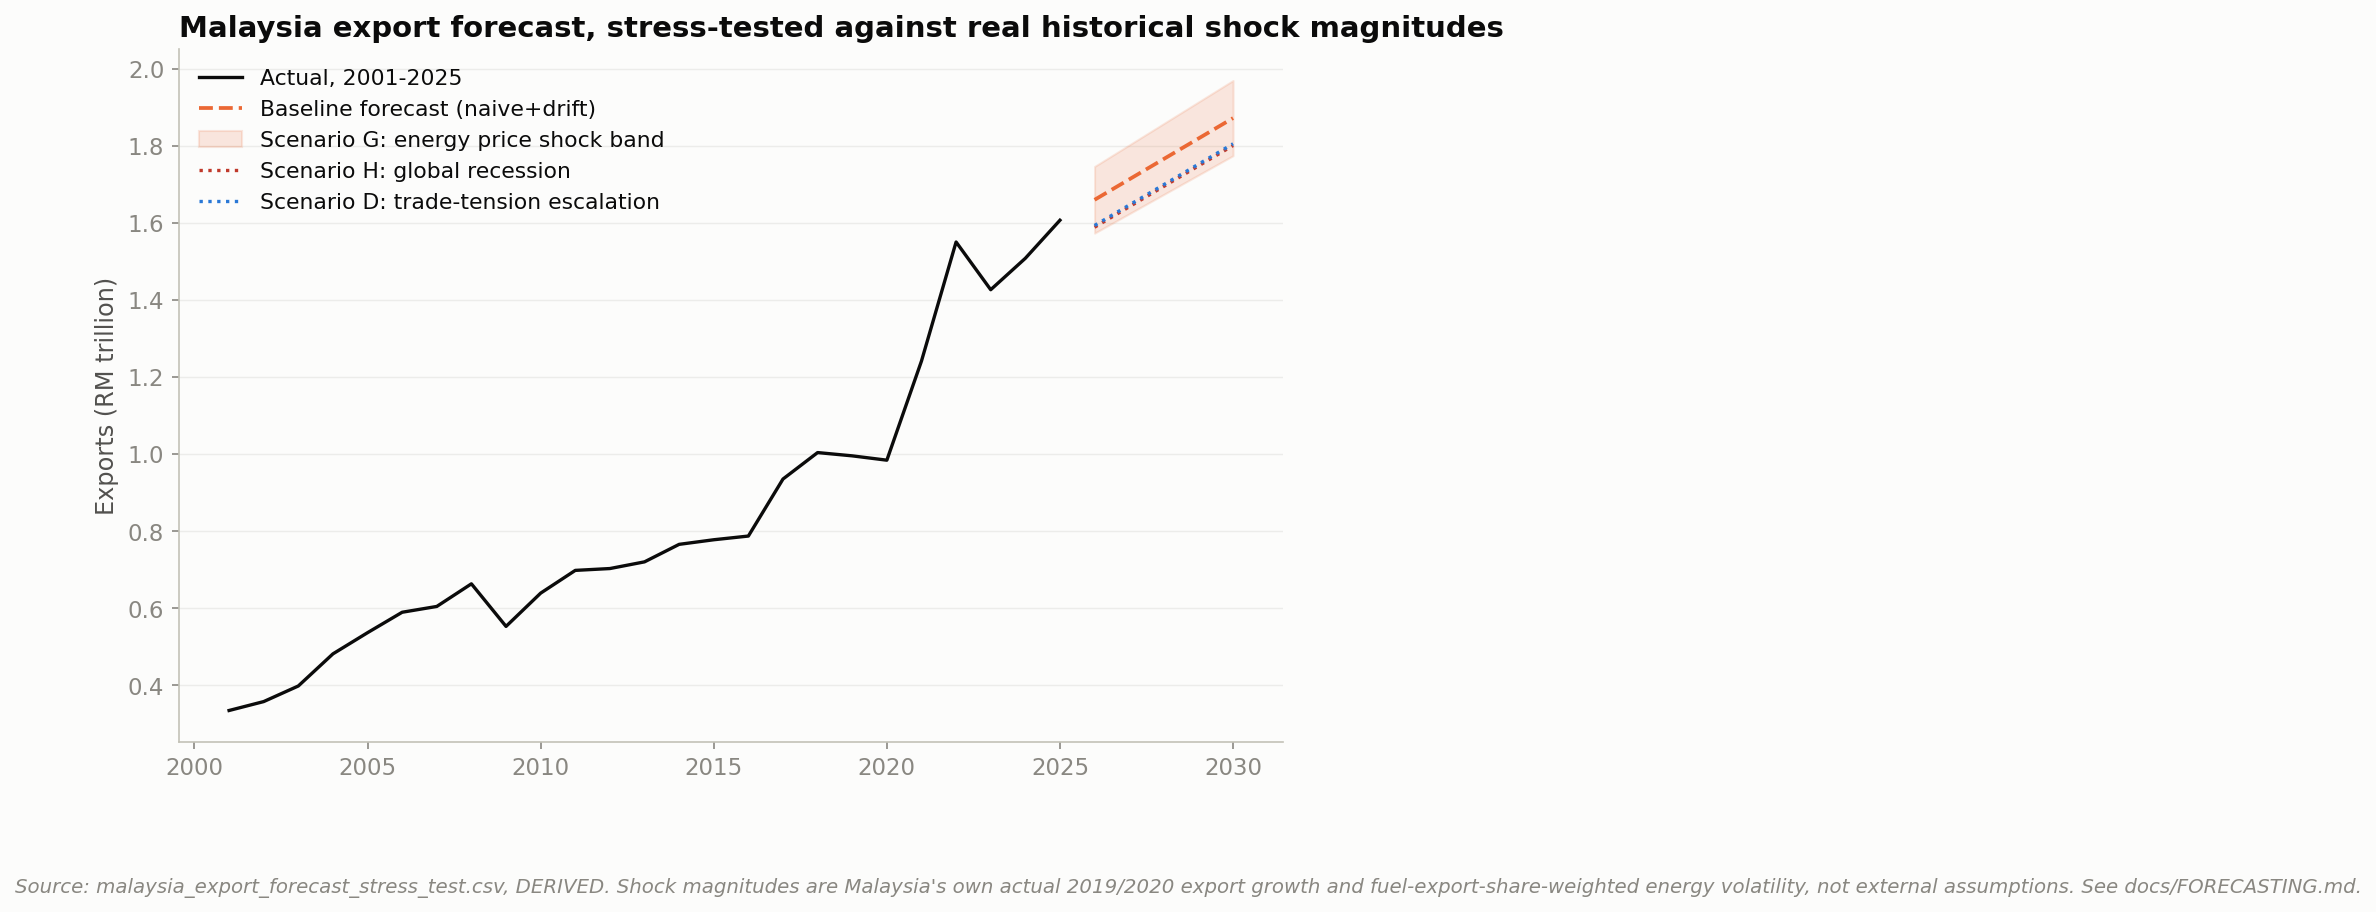

In [9]:
display(Image('../outputs/figures/19_malaysia_forecast_stress_test.png', width=950))

## Strategic Findings

### Finding 1: Risk is concentrated in small, exposed economies, and Malaysia sits mid-pack

**DATA:** The highest-risk economies on this project's four-pillar Supply Chain Risk Index (Cuba, Iran, Mongolia, Russia, Hong Kong SAR) share small, concentrated, geopolitically-exposed profiles; the lowest-risk (Germany, United States, Japan, France, China) are large, diversified, logistically strong economies. Malaysia ranks 29th of 59, genuinely mid-pack, not a standout on either end.

**INSIGHT:** Risk here is driven less by any single country's size and more by the combination of import dependency, weak logistics, concentrated trade partners, and commodity exposure acting together; Malaysia's mid-pack rank means none of these four pillars is currently acute on its own.

**BUSINESS IMPLICATION:** A blanket "Malaysia is a safe/risky supply base" claim is not well supported by this index; the honest read is that Malaysia carries moderate, broadly diversified structural risk rather than a specific acute vulnerability, which is a different risk profile to plan around than either extreme.

**STRATEGIC CONSIDERATION:** Businesses benchmarking Malaysia against alternative manufacturing or sourcing locations should compare it on this same four-pillar basis (dependency, logistics, concentration, commodity exposure) rather than a single headline score, since a mid-pack rank can hide which specific pillar matters most for a given supply chain.

### Finding 2: A validated, boring forecast beat two more sophisticated ones

**DATA:** Four forecasting models for Malaysia's exports (naive, naive-with-drift, ETS, ARIMA) were compared on a genuine five-year rolling-origin backtest, not a single train/test split. Naive-with-drift, the simplest model with a trend, produced the lowest out-of-sample RMSE, beating both ARIMA and ETS. This is reported as the winning model rather than swapped for a more "impressive-looking" one, per this project's own research-integrity standard.

**INSIGHT:** Model sophistication did not translate into forecast accuracy on this specific series; ARIMA's flexibility likely overfit patterns in the backtest windows that did not generalise forward.

**BUSINESS IMPLICATION:** A forecasting exercise that skips backtesting and defaults to the most sophisticated available model would have produced a measurably worse Malaysia export forecast than the simplest reasonable baseline, a costly mistake if that forecast fed directly into capacity or investment planning.

**STRATEGIC CONSIDERATION:** Any forecast feeding into planning or capital-allocation decisions should be validated on a real rolling-origin backtest before being trusted, regardless of how established or sophisticated the model is assumed to be; this project's own backtest discipline is a directly transferable process, not just a one-off result.

### Finding 3: Nickel's real probability of a large price move is measurable, not guessed

**DATA:** A 10,000-path historical-bootstrap Monte Carlo simulation on nickel's actual 798-month price history gives a 25-27% probability of a greater-than-20% price increase over 12 months and a 13-17% probability of a greater-than-20% decrease, with two independent bootstrap methods (independent monthly resampling and 6-month block resampling) agreeing to within 0.6% of the median.

**INSIGHT:** These probabilities come directly from nickel's real historical volatility, not an assumed distribution or a single point forecast; the close agreement between two independently-built methods is itself evidence the estimate is not an artefact of one modelling choice.

**BUSINESS IMPLICATION:** A business with nickel-price exposure (EV battery inputs, stainless steel) has a genuine, quantified basis for hedging or contract-structuring decisions here, a roughly one-in-four chance of a sharp price rise within a year, rather than a qualitative "prices could rise" statement.

**STRATEGIC CONSIDERATION:** This same historical-bootstrap approach could reasonably extend to other critical materials as matching production-concentration and price-history data becomes available (see `docs/LIMITATIONS.md` on why only nickel currently has both), turning today's one-material simulation into a broader materials-risk monitoring tool.

### Finding 4: The risk index's mid-pack ranking for Malaysia is real, but less stable than it looks

**DATA:** A 1,000-draw weight-sensitivity Monte Carlo on the Supply Chain Risk Index shows Malaysia's rank ranges from 6th to 41st of 56 complete-data countries (5th-95th percentile) depending on which of the four pillars is weighted most heavily, a genuinely wide band, alongside a real, historically-anchored forecast stress test showing the 2030 export forecast moves from RM1.87T to as low as RM1.77-1.80T under a real recession, trade-tension, or energy-shock magnitude drawn from Malaysia's own historical data.

**INSIGHT:** "Malaysia ranks 29th of 59, mid-pack" is true as a point estimate, but treating it as a stable, settled fact would be a mistake; under a supplier-concentration-weighted view specifically, Malaysia looks meaningfully riskier than the equal-weighted headline suggests. Similarly, the forecast's headline RM1.87T is a baseline, not a guarantee, and the stress test now shows exactly how much a real shock could move it.

**BUSINESS IMPLICATION:** A business or policymaker relying on "Malaysia is mid-pack risk, not a standout" as a settled input to a location or investment decision should instead ask which specific risk dimension matters most for their own exposure, since Malaysia's rank on that single dimension could look very different from its average.

**STRATEGIC CONSIDERATION:** Both additions exist specifically because a single point estimate, whether a risk rank or a forecast, understates real uncertainty; presenting the range alongside the headline number is a more honest and more useful deliverable than the headline number alone.

## Limitation

The risk index's commodity-exposure pillar is deliberately the crudest of the four (a single global-average figure, not country-specific), named explicitly, not disguised. See `docs/LIMITATIONS.md` item 6.

## Next Step

Notebook 08 brings all of this together specifically for Malaysia.
